In [26]:
import pandas as pd
import matplotlib.pyplot as plt

In [27]:
def plot_data(data):
    plt.figure(figsize=(10, 6))
    plt.scatter(data['TEST_DATE'], data['OIL'], label='Oil', color='blue')
    plt.xlabel('Time (days)')
    plt.ylabel('Production (bbl/day)')
    plt.title(data['WELL_NAME'].iloc[0])
    plt.legend()
    plt.grid()
    plt.show()



   TEST_DATE      WELL_NAME  NPD_WELL_BORE_CODE NPD_WELL_BORE_NAME  \
0 2014-04-07  NO 15/9-F-1 C                7405         15/9-F-1 C   
1 2014-04-08  NO 15/9-F-1 C                7405         15/9-F-1 C   
2 2014-04-09  NO 15/9-F-1 C                7405         15/9-F-1 C   
3 2014-04-10  NO 15/9-F-1 C                7405         15/9-F-1 C   
4 2014-04-11  NO 15/9-F-1 C                7405         15/9-F-1 C   

   NPD_FIELD_CODE NPD_FIELD_NAME  NPD_FACILITY_CODE NPD_FACILITY_NAME  \
0         3420717          VOLVE             369304    MÆRSK INSPIRER   
1         3420717          VOLVE             369304    MÆRSK INSPIRER   
2         3420717          VOLVE             369304    MÆRSK INSPIRER   
3         3420717          VOLVE             369304    MÆRSK INSPIRER   
4         3420717          VOLVE             369304    MÆRSK INSPIRER   

   ON_STREAM_HRS  AVG_DOWNHOLE_PRESSURE  ...  AVG_CHOKE_UOM  AVG_WHP_P  \
0            0.0                0.00000  ...              %    0.0

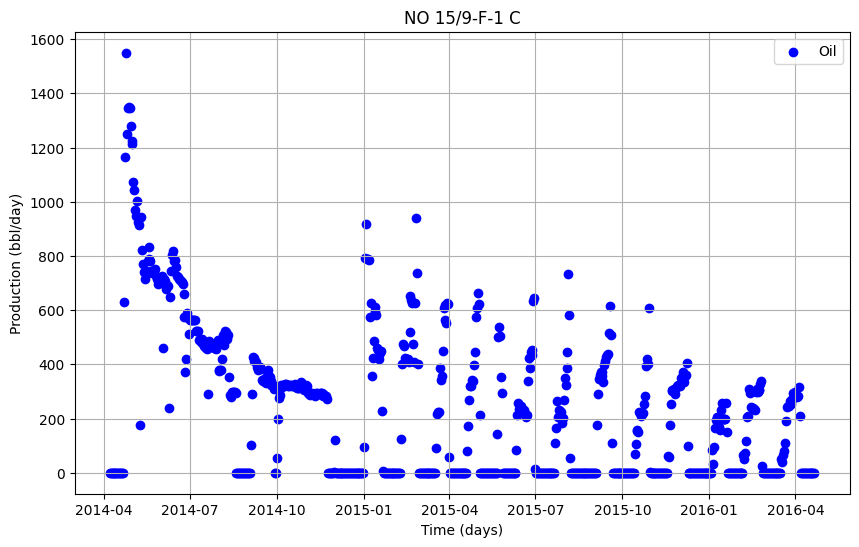

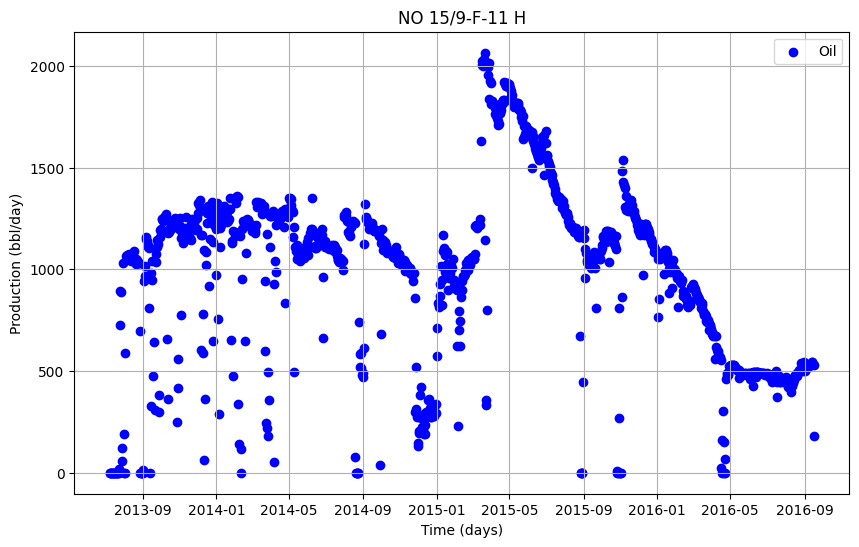

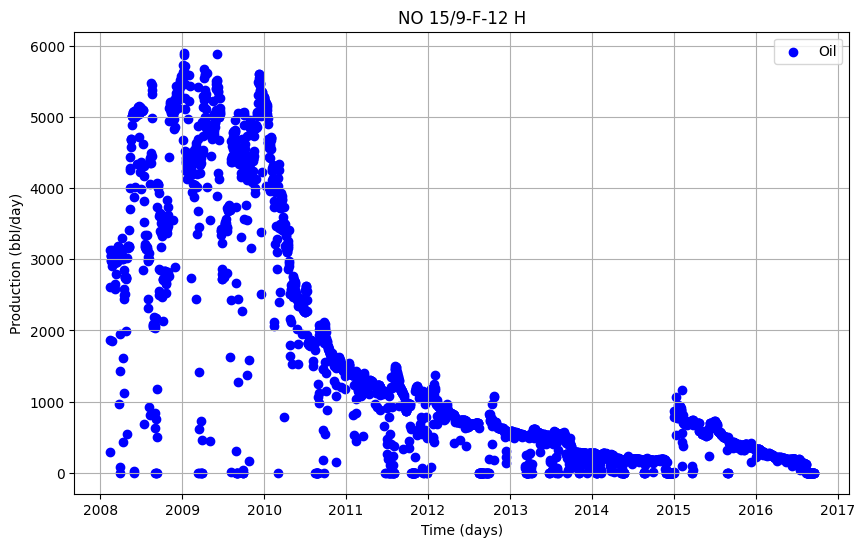

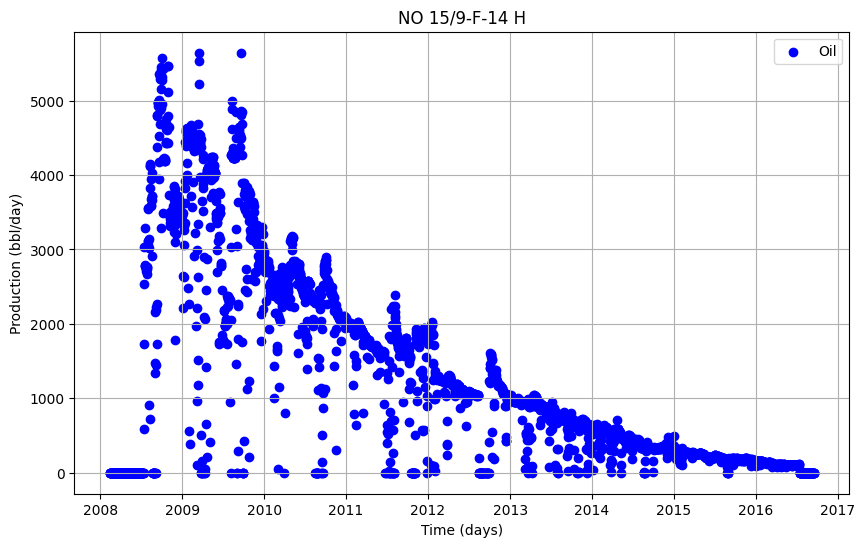

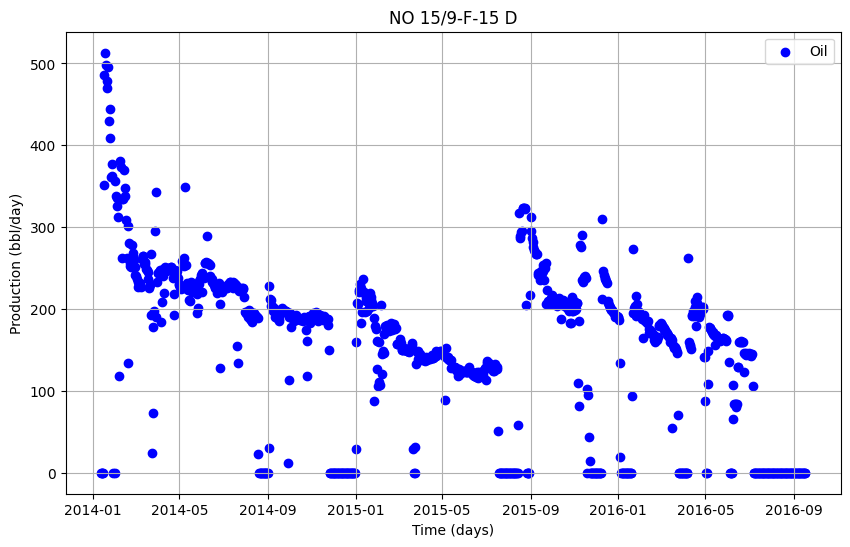

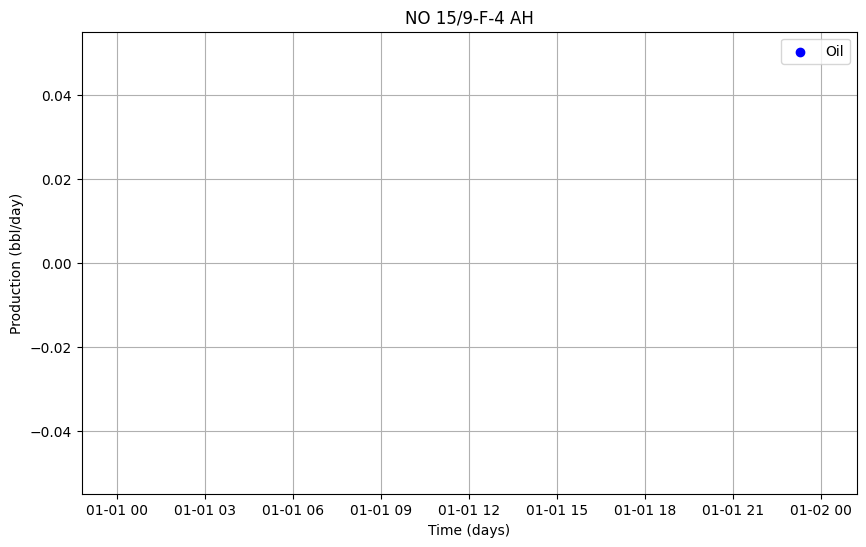

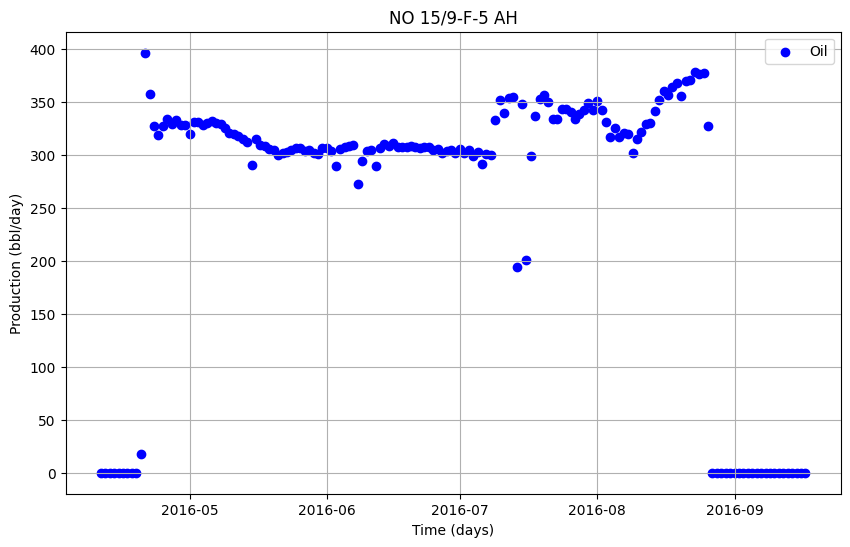

In [28]:
data = pd.read_excel("/home/rian/python_project/myvenv/dca_ml/data/Volve production data.xlsx")
to_replace=['DATEPRD','WELL_BORE_CODE','BORE_OIL_VOL','BORE_GAS_VOL']
for col in to_replace:
        if col in data.columns:
         #replace DATEPRD with TEST_DATE and BORE_OIL_VOL with OIL
            if col == 'DATEPRD':
                data.rename(columns={col: 'TEST_DATE'}, inplace=True)
                data['TEST_DATE'] = pd.to_datetime(data['TEST_DATE'])
            elif col == 'BORE_OIL_VOL':
                data.rename(columns={col: 'OIL'}, inplace=True)
            elif col=='WELL_BORE_CODE':
                data.rename(columns={col:'WELL_NAME'},inplace=True)
            elif col=='BORE_GAS_VOL':
                data.rename(columns={col:'GAS'},inplace=True)
data["TEST_DATE"] = pd.to_datetime(data["TEST_DATE"])
print(data.head())
well_names = data["WELL_NAME"].dropna().unique()
for well in well_names:
    plot_data(data[data["WELL_NAME"] == well])
    